In [ ]:
# 安裝必要套件（Colab 環境）
!pip install transformers torch scikit-learn pandas matplotlib seaborn ckip_transformers -q
!pip install -U ehownet

print("套件安裝完成！")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 6.1 MB/s eta 0:00:00
套件安裝完成！


In [ ]:
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

#中文
# 1. 安裝中文字型（Colab 用）
!apt-get install -y fonts-noto-cjk

# 2. 清除快取（保留這步）
!rm -rf ~/.cache/matplotlib

# 3. 重新載入 font manager（正確方法）
from matplotlib import font_manager
font_manager.fontManager.addfont('/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc')

# 4. 設定字型
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']
plt.rcParams['axes.unicode_minus'] = False

sns.set(font='Noto Sans CJK JP', rc={'axes.unicode_minus': False})

print("所有套件載入完成！")
print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  fonts-noto-cjk-extra
The following NEW packages will be installed:
  fonts-noto-cjk
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 61.2 MB of archives.
After this operation, 93.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk all 1:20220127+repack1-1 [61.2 MB]
Fetched 61.2 MB in 1s (41.2 MB/s)
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
所有套件載入完成！
PyTorch 版本: 2.10.0+cu128
CUDA 可用: True


In [ ]:
import torch
from ckip_transformers.nlp import CkipWordSegmenter, CkipPosTagger

# 自動判斷：如果有 GPU 則 device=0，否則 device=-1 (CPU)
device_id = 0 if torch.cuda.is_available() else -1
print(f"目前使用的裝置編號: {device_id} ({'GPU' if device_id == 0 else 'CPU'})")

# 初始化斷詞器與詞性標記器
ws_driver = CkipWordSegmenter(model="albert-base", device=device_id)
pos_driver = CkipPosTagger(model="albert-base", device=device_id)

print("CKIP 載入完成！")

目前使用的裝置編號: 0 (GPU)


config.json:   0%|          | 0.00/853 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/39.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForTokenClassification LOAD REPORT from: ckiplab/albert-base-chinese-ws
Key                            | Status     |  | 
-------------------------------+------------+--+-
albert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/40.0M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

CKIP 載入完成！




---



In [ ]:
# ============================================================
# 超參數設定
# ============================================================
MODEL_NAME = "hfl/chinese-roberta-wwm-ext"
MAX_LEN = 512
BATCH_SIZE = 8    # 資料集較小（1000筆），使用小 batch size
EPOCHS = 10       # 資料少，多訓練幾個 epoch
LR = 2e-5

Gamma=2

Lambda=0.1


# 四個預測欄位及其標籤（依照競賽官方規格定義）
EVAL_FIELDS = {
    "promise_status": ["Yes", "No"],
    "verification_timeline": ["already", "within_2_years", "between_2_and_5_years", "more_than_5_years", ""],
    "evidence_status": ["Yes", "No", ""],
    "evidence_quality": ["Clear", "Not Clear", "Misleading", ""],
}

# 各欄位的評分權重
FIELD_WEIGHTS = {
    "promise_status": 0.20,
    "evidence_status": 0.30,
    "evidence_quality": 0.35,
    "verification_timeline": 0.15,
}

# 建立標籤 ↔ ID 的對應表
label2id = {field: {lab: i for i, lab in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
id2label = {field: {i: lab for i, lab in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
num_labels = {field: len(labels) for field, labels in EVAL_FIELDS.items()}

print("超參數設定完成！")
print("\n標籤對應表：")
for field, mapping in label2id.items():
    print(f"  {field}: {mapping}")

超參數設定完成！

標籤對應表：
  promise_status: {'Yes': 0, 'No': 1}
  verification_timeline: {'already': 0, 'within_2_years': 1, 'between_2_and_5_years': 2, 'more_than_5_years': 3, '': 4}
  evidence_status: {'Yes': 0, 'No': 1, '': 2}
  evidence_quality: {'Clear': 0, 'Not Clear': 1, 'Misleading': 2, '': 3}


In [ ]:
import re
from sklearn.model_selection import train_test_split
import json
import os

# 定義檔案路徑
TRAIN_FILE = "train_grouped.json"
VAL_FILE = "val_grouped.json"

def load_split_data():
    # 檢查檔案是否存在
    if not os.path.exists(TRAIN_FILE) or not os.path.exists(VAL_FILE):
        print("❌ 錯誤：找不到切分後的 JSON 檔案！請先執行 Data Split 腳本。")
        return None, None

    # 讀取訓練集
    with open(TRAIN_FILE, "r", encoding="utf-8") as f:
        train_data = json.load(f)

    # 讀取驗證集
    with open(VAL_FILE, "r", encoding="utf-8") as f:
        val_data = json.load(f)

    print("✅ 資料載入成功！")
    print(f" - 訓練集 (train_data): {len(train_data)} 筆")
    print(f" - 驗證集 (val_data): {len(val_data)} 筆")

    return train_data, val_data

# 執行讀取
train_data, val_data = load_split_data()



✅ 資料載入成功！
 - 訓練集 (train_data): 800 筆
 - 驗證集 (val_data): 200 筆


In [ ]:
from ckip_transformers.nlp import CkipWordSegmenter
# --- 1. 定義處理函式 (包含斷詞與過濾) ---
def batch_ckip(texts, batch_size=32):
    all_ws, all_pos = [], []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        ws = ws_driver(batch)
        pos = pos_driver(ws)
        all_ws.extend(ws)
        all_pos.extend(pos)
    return all_ws, all_pos
def process_data_segmentation(data_list):
    # 提取文字
    texts = [item["data"] for item in data_list]
    # 批次斷詞
    ws_results, pos_results = batch_ckip(texts, batch_size=32)

    keep_pos_prefixes = {'N', 'V'}

    for i, (words, pos) in enumerate(zip(ws_results, pos_results)):
        filtered = [w for w, p in zip(words, pos)
                    if (p[0] in keep_pos_prefixes or p == "FW") and "CATEGORY" not in p]
        # 存回 dict
        data_list[i]['segmented_text'] = " ".join(filtered)
    return data_list

# --- 2. 執行處理 ---
print("正在處理訓練集...")
train_data = process_data_segmentation(train_data)

print("正在處理驗證集...")
val_data = process_data_segmentation(val_data)

print("✅ 預處理完成！")

# --- 3. 檢查結果 ---
print(f"訓練集範例: {train_data[0].get('segmented_text', '找不到欄位')[:100]}...")
print(f"驗證集範例: {val_data[0].get('segmented_text', '找不到欄位')[:100]}...")

正在處理訓練集...



Tokenization: 100%|██████████| 32/32 [00:00<00:00, 1635.68it/s]

Inference: 100%|██████████| 1/1 [00:02<00:00,  2.36s/it]

Tokenization: 100%|██████████| 32/32 [00:00<00:00, 628.76it/s]

Inference: 100%|██████████| 2/2 [00:02<00:00,  1.13s/it]


正在處理驗證集...


Inference: 100%|██████████| 1/1 [00:00<00:00,  3.80it/s]

✅ 預處理完成！
訓練集範例: 統一 超商 呼應 減塑 趨勢 回應 外部 關係人 包裝 包材 議題 期待 我們 持續 關注 全球 塑膠 公約 2024 年 進行 第四 次 談判 後 有 進展 統一 超商 提前 布局 設有 減塑 小組...
驗證集範例: 台積 公司 持續 落實 溫室 氣體 減 量 標竿 作為 民國  113 年 製程 端 汰換 新設 處理 設備  3,436  台 使用 碳 中 天然氣 降低 直接 排放  39  萬 公噸 二氧化碳 ...




---



In [ ]:
KEYWORDS_LIB = {
    'T1': {
        'promise': {'承諾', '保證', '保障', '確保', '允諾', '擔保', '保証', '許諾',
              '致力', '推動', '促進', '推展', '推行', '執行', '開展',
              '確立', '訂立', '建立', '制定', '設定',
              '秉持', '堅持', '遵循', '遵守', '落實', '執行', '實踐',
              '持續', '長期', '穩定', '永續', '持久',
              '計畫', '規劃', '宣示', '接軌', '納入', '協助', '改善', '制定',
              '因應', '應對', '應變', '採取措施',
              '攜手', '未來', '展望', '目標', '願景',
              'ISO', 'TCFD', 'ESG', 'GRI'},
        'esg_env': {'碳', '碳排', '排放', '碳足跡', '中和', '減碳', '減排',
              '環境', '保護', '環保', '轉型',
              '再生', '回收', '能源', '綠電', '循環', '經濟', '永續', '綠能', '清潔', '節能', '節電',
              '生物', '生態', '生態系', '多樣性',
              '氣候', '變遷', '暖化', '污染',
              '韌性', '採購', '範疇'},
        'esg_soc': {'員工', '性別', '平等', '公平', '多元', 'DEI',
              '管理', '人才', '發展', '培育', '招募', '教育', '訓練', '學習', '留才', '離職率',
              '社會', '責任', 'CSR',
              '人權', '政策', '保障', '勞動', '勞工', '童工',
              '福利', '關懷', '滿意度', '敬業度', '勞資',
              '薪資', '薪酬', '工時', '條件',
              '職場', '職安', '職災', '職涯',
              '包容', '平權', '歧視', '性騷擾',
              '公益', '志工', '志願'},
        'esg_gov': {'董事會', '理事會', '監察人', '委員會', '公司',
              '合規', '法遵', '規範', '法規', '法令',
              '透明', '揭露', '公開',
              '風險', '風控', '評估', '控管', '監控', '內控', '管控', '控制',
              '誠信', '道德', '廉潔', '經營', '倫理',
              '經營', '營運', '管理', '策略', '治理',
              '貪腐', '賄賂', '舞弊',
              '審計', '稽核', '查核',
              '資安', '安全', '個資', '隱私',
              '薪酬', '薪資', '報酬', '獎酬', '制度', '機制'}
    },
    'T2_T3': {
        'clear': {'完成', '達到', '達成', '實現',
              '建立', '設立', '成立', '制定',
              '通過', '批准', '認可', '取得', '獲得',
              '削減', '降低', '減少', '減緩', '節省',
              '符合', '遵循', '遵守', '依循',
              '辦理', '執行', '實施', '推行', '運作',
              '落實', '實行', '實踐', '導入', '應用',
              '改善', '優化', '提升', '精進', '改進',
              '汰舊換新', '更新', '升級', '換代',
              '稽核', '審核', '查核', '檢查',
              '編列', '規劃', '安排', '列入',
              '認證', '證明', '核可', '驗證',
              '採用', '使用', '運用', '導入',
              '轉型', '改造',
              '%'},
        'not_clear': {'計畫', '規劃', '安排', '設計', '籌劃',
                '期盼', '期望', '希望', '願景',
                '呼應', '響應', '配合', '回應',
                '內部', '內控','自我', '自我', '自主',
                '應', '應對', '採取', '應用',
                '考量', '考慮', '評估', '權衡',
                '攜手','致力'},
        'misleading': {'領先', '最', '全方位', '世界級', '極致'}
    },
    'T4': {
        'already': {'2023', '2024', '去年', '當年度', '已', '目前', '完成', '達成', '以往', '歷年', '累計', '前一年度','過去'},
        'within_2y': {'2026', '2027', '明年', '下年度', '即將', '近兩年', '短期', '近期', '首要目標'},
        'between_2_5y': {'2029', '2030', '中期', '階段性', '中程'},
        'above_5y': {'2040', '2050' , '長期', '遠期','終極目標','持續'}
    }
}

In [ ]:
SEMANTIC_CLASSES = {
    'promise': 0,
    'evidence': 1,
    'quality_score': 2,
    'timeline_score': 3
}

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vec   = TfidfVectorizer(max_features=5000)
train_texts = [item["segmented_text"] for item in train_data]
val_texts   = [item["segmented_text"] for item in val_data]

tfidf_train = tfidf_vec.fit_transform(train_texts)   # fit + transform 訓練集
tfidf_val   = tfidf_vec.transform(val_texts)          # 只 transform 驗證集
word_to_idx = tfidf_vec.vocabulary_
print(f"✅ TF-IDF 建立完成：訓練集 {tfidf_train.shape}, 驗證集 {tfidf_val.shape}")

✅ TF-IDF 建立完成：訓練集 (800, 5000), 驗證集 (200, 5000)


In [ ]:
def extract_semantic_features(
    text,
    text_idx,
    keywords_lib,
    semantic_classes,
    tfidf_matrix,
    word_to_idx,
    debug=False
):
    vec = [0.0] * len(semantic_classes)

    # sparse row（避免 toarray）
    sample_vec = tfidf_matrix[text_idx]

    def get_tfidf_sum(word_set):
        total = 0.0
        for word in word_set:
            idx = word_to_idx.get(word)
            if idx is not None:
                total += sample_vec[0, idx]
        return total

    # =========================
    # 1. Promise
    # =========================
    t1_score = 0
    promise_t = get_tfidf_sum(keywords_lib['T1']['promise'])
    esg_t = get_tfidf_sum(
        keywords_lib['T1']['esg_env'] |
        keywords_lib['T1']['esg_soc'] |
        keywords_lib['T1']['esg_gov']
    )

    promise_c = sum(w in text for w in keywords_lib['T1']['promise'])
    esg_c = sum(w in text for w in (
      keywords_lib['T1']['esg_env'] |
      keywords_lib['T1']['esg_soc'] |
      keywords_lib['T1']['esg_gov']
    ))

    if promise_c>=1 and esg_c>=1:
        t1_score = (
          promise_c* promise_t
          +esg_c*esg_t
        )
    if debug:
      print("=== T1 ===")
      print("promise_t:", promise_t, "count:", promise_c, "contrib:", promise_c * promise_t)
      print("esg_t:", esg_t, "count:", esg_c, "contrib:", esg_c * esg_t)
      print("t1_score:", t1_score)

    vec[semantic_classes['promise']] = min(t1_score, 2.0)

    # =========================
    # 2. Evidence
    # =========================
    t2_score = 0

    evidence_t = get_tfidf_sum(
        keywords_lib['T2_T3']['clear'] |
        keywords_lib['T2_T3']['not_clear'] |
        keywords_lib['T2_T3']['misleading']
    )
    t2_all = (keywords_lib['T2_T3']['clear'] |
              keywords_lib['T2_T3']['not_clear'] |
              keywords_lib['T2_T3']['misleading']
              )
    evidence_c = sum(1 for w in t2_all if w in text)
    t2_score = (evidence_c*evidence_t)
    if debug:
      print("=== T2 ===")
      print("evidence_t:",evidence_t)
      print("evidence_c:", evidence_c)
      print("t2_score:", t2_score)

    vec[semantic_classes['evidence']] = min(t2_score, 2.0)

    # =========================
    # 3. Quality score
    # =========================
    t3_score = 0

    clear_t = get_tfidf_sum(keywords_lib['T2_T3']['clear'])
    not_clear_t = get_tfidf_sum(keywords_lib['T2_T3']['not_clear'])
    mis_t = get_tfidf_sum(keywords_lib['T2_T3']['misleading'])

    clear_c = sum(1 for w in keywords_lib['T2_T3']['clear'] if w in text)
    not_clear_c = sum(1 for w in keywords_lib['T2_T3']['not_clear'] if w in text)
    misleading_c = sum(1 for w in keywords_lib['T2_T3']['misleading'] if w in text)

    t3_score = (
      clear_c * clear_t
      - not_clear_c * not_clear_t
      - misleading_c* mis_t
    )
    if debug:
      print("=== T3 ===")
      print("clear_t:", clear_t, "count:", clear_c, "contrib:", clear_c * clear_t)
      print("not_clear_t:", not_clear_t, "count:", not_clear_c, "contrib:", -not_clear_c * not_clear_t)
      print("mis_t:", mis_t, "count:", misleading_c, "contrib:", -misleading_c * mis_t)
      print("t3_score:", t3_score)
    vec[semantic_classes['quality_score']] = max(min(t3_score, 2.0), -2.0)

    # =========================
    # 4. Timeline
    # =========================
    t4_score = 0

    already_c = sum(1 for w in keywords_lib['T4']['already'] if w in text)
    within_c = sum(1 for w in keywords_lib['T4']['within_2y'] if w in text)
    mid_c = sum(1 for w in keywords_lib['T4']['between_2_5y'] if w in text)
    long_c = sum(1 for w in keywords_lib['T4']['above_5y'] if w in text)

    already_t = get_tfidf_sum(keywords_lib['T4']['already'])
    within_t = get_tfidf_sum(keywords_lib['T4']['within_2y'])
    mid_t = get_tfidf_sum(keywords_lib['T4']['between_2_5y'])
    long_t = get_tfidf_sum(keywords_lib['T4']['above_5y'])

    t4_score = (
        already_c * already_t+
        within_c *  within_t+
        mid_c *  mid_t+
        long_c *  long_t
    )

    if debug:
      print("=== T4 ===")
      print("already:", already_c, "*", already_t, "=", already_c * already_t)
      print("within_2y:", within_c, "*", within_t, "=", within_c * within_t)
      print("2_5y:", mid_c, "*", mid_t, "=", mid_c * mid_t)
      print("above_5y:", long_c, "*", long_t, "=", long_c * long_t)

    vec[semantic_classes['timeline_score']] = min(t4_score, 2.0)

    return torch.tensor(vec, dtype=torch.float)

In [ ]:
import torch
from torch.utils.data import Dataset

class ESGDataset(Dataset):
    def __init__(self, data, tokenizer, label2id, keywords_lib, semantic_classes, tfidf_matrix, word_to_idx):
        self.data = data
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.keywords_lib = keywords_lib
        self.semantic_classes = semantic_classes
        self.num_extra_features = len(semantic_classes)
        self.tfidf_matrix = tfidf_matrix
        self.word_to_idx = word_to_idx

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = item["data"]

        # BERT Tokenization
        encoding = self.tokenizer(text, max_length=MAX_LEN, padding="max_length",
                                  truncation=True, return_tensors="pt")

        # 定義的函式提取特徵
        extra_features = extract_semantic_features(
            text,
            idx,
            self.keywords_lib,
            self.semantic_classes,
            self.tfidf_matrix,
            self.word_to_idx
        )
        # 標籤映射
        labels = {field: self.label2id[field][item[field]] for field in EVAL_FIELDS}

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "extra_features": extra_features,
            "labels": labels,
        }

def collate_fn(batch):
    """
    整合 batch，包含處理額外特徵向量
    """
    input_ids = torch.stack([b["input_ids"] for b in batch])
    attention_mask = torch.stack([b["attention_mask"] for b in batch])

    # 疊加額外特徵 [Batch_Size, Num_Extra_Features]
    extra_features = torch.stack([b["extra_features"] for b in batch])

    labels = {
        field: torch.tensor([b["labels"][field] for b in batch])
        for field in EVAL_FIELDS
    }

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "extra_features": extra_features, # 餵給模型 forward 的參數
        "labels": labels
    }

In [ ]:
# 示範 Tokenizer 的效果
print("Tokenizer 示範")
print("=" * 50)

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f"載入 {MODEL_NAME} tokenizer")

sample_text = train_data[0]["segmented_text"][:50]
print(f"\n原始文字：{sample_text}")

tokens = tokenizer.tokenize(train_data[0]["segmented_text"])
print(f"\nTokenize 後：{tokens}")

encoding = tokenizer(sample_text, max_length=20, padding="max_length", truncation=True)
print(f"\nInput IDs (前20個)：{encoding['input_ids']}")
print(f"Attention Mask：{encoding['attention_mask']}")

features = extract_semantic_features(
    text=train_data[0]["segmented_text"],
    text_idx=0,
    keywords_lib=KEYWORDS_LIB,
    semantic_classes=SEMANTIC_CLASSES,
    tfidf_matrix=tfidf_train,
    word_to_idx=word_to_idx,
    debug=True
)

print(features)



Tokenizer 示範


tokenizer_config.json:   0%|          | 0.00/19.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

載入 hfl/chinese-roberta-wwm-ext tokenizer

原始文字：統一 超商 呼應 減塑 趨勢 回應 外部 關係人 包裝 包材 議題 期待 我們 持續 關注 全球 塑

Tokenize 後：['統', '一', '超', '商', '呼', '應', '減', '塑', '趨', '勢', '回', '應', '外', '部', '關', '係', '人', '包', '裝', '包', '材', '議', '題', '期', '待', '我', '們', '持', '續', '關', '注', '全', '球', '塑', '膠', '公', '約', '202', '##4', '年', '進', '行', '第', '四', '次', '談', '判', '後', '有', '進', '展', '統', '一', '超', '商', '提', '前', '布', '局', '設', '有', '減', '塑', '小', '組', '主', '責', '管', '理', '採', '取', '積', '極', '行', '動', '確', '保', '依', '循', '環', '境', '部', '減', '塑', '法', '規', '消', '費', '者', '供', '應', '商', '減', '少', '塑', '膠', '用', '量', '自', '有', '品', '牌', '商', '品', '包', '裝', '包', '材', '設', '定', '完', '整', '管', '理', '政', '策', '目', '標', '2030', '年', '前', '自', '有', '商', '品', '包', '裝', '物', '料', '2019', '年', '減', '少', '30', '%', '塑', '膠', '使', '用', '量', '自', '有', '商', '品', '包', '裝', '物', '料', '50', '%', '轉', '換', '為', '環', '保', '材', '質', '統', '一', '超', '商', '積', '極', '採', '取', '減', '塑', '管', '理', '行', '動', '結', '合', '自', '有', '商

In [ ]:
# 建立 Dataset 實例
train_dataset = ESGDataset(
    train_data, tokenizer, label2id,
    KEYWORDS_LIB, SEMANTIC_CLASSES,
    tfidf_train, word_to_idx
)

val_dataset = ESGDataset(
    val_data, tokenizer, label2id,
    KEYWORDS_LIB, SEMANTIC_CLASSES,
    tfidf_val, word_to_idx
)


# 建立 DataLoader（負責批次載入資料）
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,          # 訓練時打亂順序
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,         # 驗證時不打亂
    collate_fn=collate_fn
)

print(f"DataLoader 建立完成！")
print(f"   訓練集 Batch 數: {len(train_loader)}")
print(f"   驗證集 Batch 數: {len(val_loader)}")

# 查看一個 batch 的結構
sample_batch = next(iter(train_loader))
print(f"\nBatch 結構：")
print(f"   input_ids shape: {sample_batch['input_ids'].shape}  # [batch_size, seq_len]")
print(f"   attention_mask shape: {sample_batch['attention_mask'].shape}")
for field, tensor in sample_batch['labels'].items():
    print(f"   labels['{field}'] shape: {tensor.shape}")

DataLoader 建立完成！
   訓練集 Batch 數: 100
   驗證集 Batch 數: 25

Batch 結構：
   input_ids shape: torch.Size([8, 512])  # [batch_size, seq_len]
   attention_mask shape: torch.Size([8, 512])
   labels['promise_status'] shape: torch.Size([8])
   labels['verification_timeline'] shape: torch.Size([8])
   labels['evidence_status'] shape: torch.Size([8])
   labels['evidence_quality'] shape: torch.Size([8])


In [ ]:
class MultiTaskBert(nn.Module):
    def __init__(self, num_labels_dict, extra_feat_dim=4):
        super().__init__()
        self.bert = BertModel.from_pretrained(MODEL_NAME)
        # 計算總輸入維度：BERT(768) + 專家特徵(4) = 772
        self.combined_dim = 768 + extra_feat_dim

        # 修改所有的分類器，使其接收 772 維
        self.classifier_promise = nn.Linear(self.combined_dim, num_labels_dict['promise_status'])
        self.classifier_evidence = nn.Linear(self.combined_dim, num_labels_dict['evidence_status'])
        self.classifier_quality = nn.Linear(self.combined_dim, num_labels_dict['evidence_quality'])
        self.classifier_timeline = nn.Linear(self.combined_dim, num_labels_dict['verification_timeline'])

        self.dropout = nn.Dropout(0.2)

    def forward(self, input_ids, attention_mask, extra_features):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output

        extra_features = F.normalize(extra_features, dim=1)

        # 維度[batch_size, 772]
        combined_features = torch.cat((pooled_output, extra_features), dim=1)

        # 傳入 772 維到 Linear(772, n)
        logits = {
            'promise_status': self.classifier_promise(combined_features),
            'evidence_status': self.classifier_evidence(combined_features),
            'evidence_quality': self.classifier_quality(combined_features),
            'verification_timeline': self.classifier_timeline(combined_features)
        }
        return {'logits': logits, 'embeddings': pooled_output}

# 初始化模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiTaskBert(num_labels).to(device)

print("模型維度為 BERT(768) + 專家特徵(4) = 772！")

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/412M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: hfl/chinese-roberta-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 761, in hf_raise_for_status
    respon

模型維度為 BERT(768) + 專家特徵(4) = 772！


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # 各類別的權重
        self.gamma = gamma  # 難度調節因子
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs: [batch_size, num_classes] (模型輸出的 Logits)
        # targets: [batch_size] (正確標籤)

        # 1. 計算交叉熵 (不進行平均)
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')

        # 2. 計算 pt (預測正確類別的機率)
        pt = torch.exp(-ce_loss)

        # 3. 計算 Focal Loss: (1-pt)^gamma * ce_loss
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def train_one_epoch(model, dataloader, optimizer, scheduler, device,
                    field_weights=None, lambda_con=0.1):

    model.train()
    total_loss = 0

    contrastive_fn = torch.nn.CosineEmbeddingLoss(margin=0.5).to(device)

    criterions = {}
    for field in EVAL_FIELDS:
        weight = field_weights[field].to(device) if field_weights else None
        criterions[field] = FocalLoss(alpha=weight, gamma=Gamma).to(device)

    for step, batch in enumerate(dataloader):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        extra_features = batch["extra_features"].to(device)

        output = model(input_ids, attention_mask, extra_features)

        logits = output["logits"]
        emb = output["embeddings"]

        batch_loss = 0

        for field in EVAL_FIELDS:

            target = batch["labels"][field].to(device)

            ce_loss = criterions[field](logits[field], target)

            # contrastive loss（保留）
            con_loss = 0
            mask = (target != -100)

            if mask.sum() > 1:
                v_emb = emb[mask]
                v_target = target[mask]

                v_emb_shifted = torch.roll(v_emb, shifts=1, dims=0)
                v_target_shifted = torch.roll(v_target, shifts=1, dims=0)

                y_con = torch.where(v_target == v_target_shifted, 1, -1).to(device)
                con_loss = contrastive_fn(v_emb, v_emb_shifted, y_con)

            batch_loss += FIELD_WEIGHTS[field] * (
                ce_loss + lambda_con * con_loss
            )

        optimizer.zero_grad()
        batch_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += batch_loss.item()

        if (step + 1) % 50 == 0:
            print(f"Step {step+1}/{len(dataloader)}, Loss: {batch_loss.item():.4f}")

    return total_loss / len(dataloader)

print("訓練函數定義完成！")

訓練函數定義完成！


In [ ]:
def predict(model, dataloader, device, id2label):
    """
    對資料集進行預測，並強制執行級聯後處理規則。
    適配對比學習模型輸出格式。
    """
    model.eval()
    predictions = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            extra_features = batch["extra_features"].to(device)

            # --- 解包模型回傳的 dict ---
            output = model(input_ids, attention_mask, extra_features)
            logits = output['logits']  # 取得分類用的 Logits

            batch_size = input_ids.size(0)
            for i in range(batch_size):
                pred = {}
                # 取得每個欄位的原始預測結果
                for field in EVAL_FIELDS:
                    # logits[field] 形狀為 [batch_size, num_classes]
                    pred_id = logits[field][i].argmax().item()
                    pred[field] = id2label[field][pred_id]

                # --- 執行級聯規則修正 (後處理) ---
                # 這部分能確保模型輸出的逻辑一致性，特別是加入對比學習後更能強化正負樣本界線

                # 規則 A: 如果預測為沒有承諾 (promise_status == 'No')
                if pred['promise_status'] == 'No':
                    pred['verification_timeline'] = ''
                    pred['evidence_status'] = ''
                    pred['evidence_quality'] = ''

                # 規則 B: 如果有承諾但預測為沒有佐證 (evidence_status == 'No')
                elif pred['evidence_status'] == 'No':
                    pred['evidence_quality'] = ''

                predictions.append(pred)

    return predictions

print("預測函數定義完成！")

預測函數定義完成！


In [ ]:
def evaluate_hybrid(gt_data, pred_data):
    """
    混合評估函數：加權 Macro F1

    Args:
        gt_data: Ground truth 資料列表
        pred_data: 預測結果列表（順序需與 gt_data 一致）

    Returns:
        results: 各欄位的評估結果 + 最終加權分數
    """
    assert len(gt_data) == len(pred_data), \
        f"筆數不符：gt={len(gt_data)}, pred={len(pred_data)}"

    results = {}
    weighted_score = 0.0

    for field, labels in EVAL_FIELDS.items():
        y_true = [str(item[field]).strip() for item in gt_data]
        y_pred = [str(item[field]).strip() for item in pred_data]


        if epoch == 0:
          print(f"DEBUG [{field}] - True: '{y_true[0]}', Pred: '{y_pred[0]}'")
          print(f"DEBUG - Are they equal? {y_true[0] == y_pred[0]}")
        clean_labels = [str(l).strip() for l in labels]
        # Macro F1: 每個類別分別計算 F1，再取平均（不考慮類別數量）
        macro_f1 = f1_score(y_true, y_pred, labels=clean_labels, average="macro", zero_division=0)
        # Micro F1: 全部類別合併計算（考慮類別數量）
        micro_f1 = f1_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)
        report   = classification_report(y_true, y_pred, labels=labels, zero_division=0)

        weight = FIELD_WEIGHTS.get(field, 0)
        weighted_score += macro_f1 * weight

        results[field] = {
            "macro_f1": macro_f1,
            "micro_f1": micro_f1,
            "report": report,
            "weight": weight
        }

    results["final_weighted_score"] = weighted_score
    return results


print(" 評估函數定義完成！")
print("\n Macro F1 vs Micro F1 說明：")
print("   Macro F1: 各類別同等重要，不受樣本數影響 → 用於評估少數類別")
print("   Micro F1: 樣本數多的類別影響較大 → 整體準確率指標")

 評估函數定義完成！

 Macro F1 vs Micro F1 說明：
   Macro F1: 各類別同等重要，不受樣本數影響 → 用於評估少數類別
   Micro F1: 樣本數多的類別影響較大 → 整體準確率指標


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

field_loss_weights = {}

for field in EVAL_FIELDS:
    # 1. 取得該欄位在訓練集中的所有實際標籤
    y_train = [item[field] for item in train_data]

    # 2. 找出「實際存在」於 y_train 中的類別

    present_classes = np.unique(y_train)

    # 3. 計算這些存在類別的權重
    weights = compute_class_weight(
        class_weight='balanced',
        classes=present_classes,
        y=np.array(y_train)
    )

    # 4. 建立一個對應完整 EVAL_FIELDS 的權重 Tensor（預設權重為 1.0）
    full_weights = np.ones(len(EVAL_FIELDS[field]))
    for i, cls_name in enumerate(EVAL_FIELDS[field]):
        if cls_name in present_classes:
            # 找到該類別在 compute_class_weight 結果中的位置
            idx = np.where(present_classes == cls_name)[0][0]
            full_weights[i] = weights[idx]

    # 5. 轉為 Tensor
    field_loss_weights[field] = torch.tensor(full_weights, dtype=torch.float).to(device)

    print(f"✅ {field} 權重已對齊: {dict(zip(EVAL_FIELDS[field], full_weights))}")

✅ promise_status 權重已對齊: {'Yes': np.float64(0.60882800608828), 'No': np.float64(2.797202797202797)}
✅ verification_timeline 權重已對齊: {'already': np.float64(0.5298013245033113), 'within_2_years': np.float64(13.333333333333334), 'between_2_and_5_years': np.float64(0.8602150537634409), 'more_than_5_years': np.float64(1.019108280254777), '': np.float64(1.118881118881119)}
✅ evidence_status 權重已對齊: {'Yes': np.float64(0.4884004884004884), 'No': np.float64(2.4024024024024024), '': np.float64(1.8648018648018647)}
✅ evidence_quality 權重已對齊: {'Clear': np.float64(0.4484304932735426), 'Not Clear': np.float64(2.0202020202020203), 'Misleading': np.float64(200.0), '': np.float64(0.7874015748031497)}


In [ ]:
from transformers import get_cosine_schedule_with_warmup

# 設定優化器與學習率排程器
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.1 * total_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"訓練設定：")
print(f"   Total steps: {total_steps}")
print(f"   Warmup steps: {warmup_steps} (前 10%)")
print(f"   Learning rate: {LR}")
print(f"   Optimizer: AdamW")

訓練設定：
   Total steps: 1000
   Warmup steps: 100 (前 10%)
   Learning rate: 2e-05
   Optimizer: AdamW


In [ ]:
# ============================================================
# 主訓練迴圈
# ============================================================
MODEL_SAVE_PATH = "best_model.pt"

best_score = 0.0
history = {"loss": [], "weighted_score": []}

print("開始訓練！")
print("=" * 60)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    # 訓練
    avg_loss = train_one_epoch(model, train_loader, optimizer, scheduler, device, field_loss_weights, lambda_con=Lambda)
    history["loss"].append(avg_loss)
    print(f"  平均 Loss: {avg_loss:.4f}")

    # 在驗證集上評估
    preds   = predict(model, val_loader, device, id2label)
    results = evaluate_hybrid(val_data, preds)

    current_score = results["final_weighted_score"]
    history["weighted_score"].append(current_score)

    print(f"\n  加權分數: {current_score:.5f}")
    for field in EVAL_FIELDS:
        r = results[field]
        print(f"     {field}: Macro F1={r['macro_f1']:.4f} (權重={r['weight']})")

    # 儲存最佳模型
    if current_score > best_score:
        best_score = current_score
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"\n 最佳模型已儲存！分數: {best_score:.5f}")

print(f"\n{'=' * 60}")
print(f"訓練完成！最佳加權分數: {best_score:.5f}")

開始訓練！

Epoch 1/10
----------------------------------------
Step 50/100, Loss: 0.3995
Step 100/100, Loss: 30.0561
  平均 Loss: 0.8235
DEBUG [promise_status] - True: 'Yes', Pred: 'No'
DEBUG - Are they equal? False
DEBUG [verification_timeline] - True: 'between_2_and_5_years', Pred: ''
DEBUG - Are they equal? False
DEBUG [evidence_status] - True: 'Yes', Pred: ''
DEBUG - Are they equal? False
DEBUG [evidence_quality] - True: 'Clear', Pred: ''
DEBUG - Are they equal? False

  加權分數: 0.15829
     promise_status: Macro F1=0.2572 (權重=0.2)
     verification_timeline: Macro F1=0.1221 (權重=0.15)
     evidence_status: Macro F1=0.1336 (權重=0.3)
     evidence_quality: Macro F1=0.1385 (權重=0.35)

 最佳模型已儲存！分數: 0.15829

Epoch 2/10
----------------------------------------
Step 50/100, Loss: 0.4944
Step 100/100, Loss: 0.2213
  平均 Loss: 0.7567

  加權分數: 0.31259
     promise_status: Macro F1=0.5963 (權重=0.2)
     verification_timeline: Macro F1=0.2669 (權重=0.15)
     evidence_status: Macro F1=0.3154 (權重=0.3)
     e

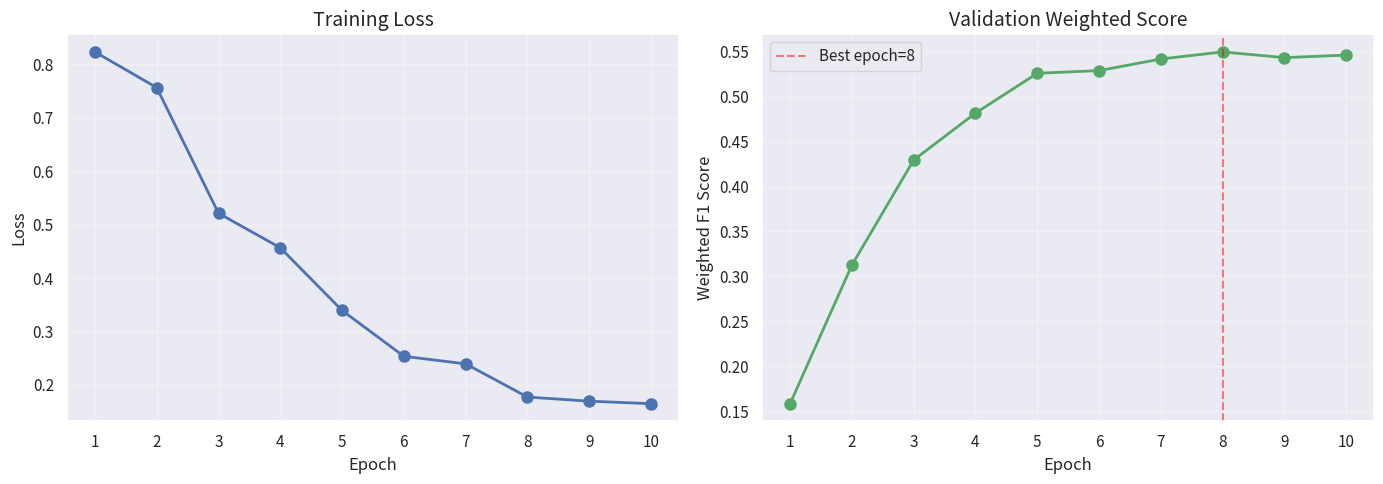

In [ ]:
# 繪製訓練曲線
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history["loss"], 'b-o', linewidth=2, markersize=8)
axes[0].set_title("Training Loss", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(epochs_range)

axes[1].plot(epochs_range, history["weighted_score"], 'g-o', linewidth=2, markersize=8)
axes[1].set_title("Validation Weighted Score", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Weighted F1 Score")
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(epochs_range)

# 標記最佳點
best_epoch = history["weighted_score"].index(max(history["weighted_score"])) + 1
axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best epoch={best_epoch}')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curve.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import json
import pandas as pd

# 載入最佳模型
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
print(f"已載入最佳模型")

# 最終預測
final_preds = predict(model, val_loader, device, id2label)

# ========= 只保留需要欄位 =========
OUTPUT_JSON = "bert_prediction.json"
OUTPUT_CSV = "bert_prediction.csv"

output_data = []

for orig, pred in zip(val_data, final_preds):

    cleaned_pred = {
        k: ("N/A" if v == "" or v is None else v)
        for k, v in pred.items() if k in ["promise_status", "verification_timeline", "evidence_status", "evidence_quality"]
    }

    item = {
        "id": orig["id"],
        "promise_status": cleaned_pred.get("promise_status", "N/A"),
        "verification_timeline": cleaned_pred.get("verification_timeline", "N/A"),
        "evidence_status": cleaned_pred.get("evidence_status", "N/A"),
        "evidence_quality": cleaned_pred.get("evidence_quality", "N/A")
    }

    output_data.append(item)


# ========= 儲存 JSON =========
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(output_data, f, ensure_ascii=False, indent=2)

print(f"✅ JSON 已儲存至: {OUTPUT_JSON}")

# ========= 儲存 CSV =========
df = pd.DataFrame(output_data)
df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print(f"✅ CSV 已儲存至: {OUTPUT_CSV}")

print(f"   共 {len(output_data)} 筆")

# ========= 評估 =========
final_results = evaluate_hybrid(val_data, final_preds)

print(f"\n{'=' * 60}")
print(f"最終評估結果")
print(f"{'=' * 60}")

for field in EVAL_FIELDS:
    r = final_results[field]

    print(f"\n--- {field} (權重: {r['weight']}) ---")
    print(r["report"])
    print(f"  Macro F1: {r['macro_f1']:.4f}")
    print(f"  Micro F1: {r['micro_f1']:.4f}")

print(f"\n{'=' * 60}")
print(f"最終加權分數: {final_results['final_weighted_score']:.5f}")
print(f"{'=' * 60}")

已載入最佳模型
✅ JSON 已儲存至: bert_prediction.json
✅ CSV 已儲存至: bert_prediction.csv
   共 200 筆

最終評估結果

--- promise_status (權重: 0.2) ---
              precision    recall  f1-score   support

         Yes       0.89      0.92      0.91       157
          No       0.68      0.58      0.62        43

    accuracy                           0.85       200
   macro avg       0.78      0.75      0.77       200
weighted avg       0.84      0.85      0.85       200

  Macro F1: 0.7656
  Micro F1: 0.8500

--- verification_timeline (權重: 0.15) ---
                       precision    recall  f1-score   support

              already       0.51      0.61      0.55        64
       within_2_years       0.00      0.00      0.00         1
between_2_and_5_years       0.50      0.40      0.45        52
    more_than_5_years       0.61      0.68      0.64        40
                            0.68      0.58      0.62        43

             accuracy                           0.56       200
            macro avg  

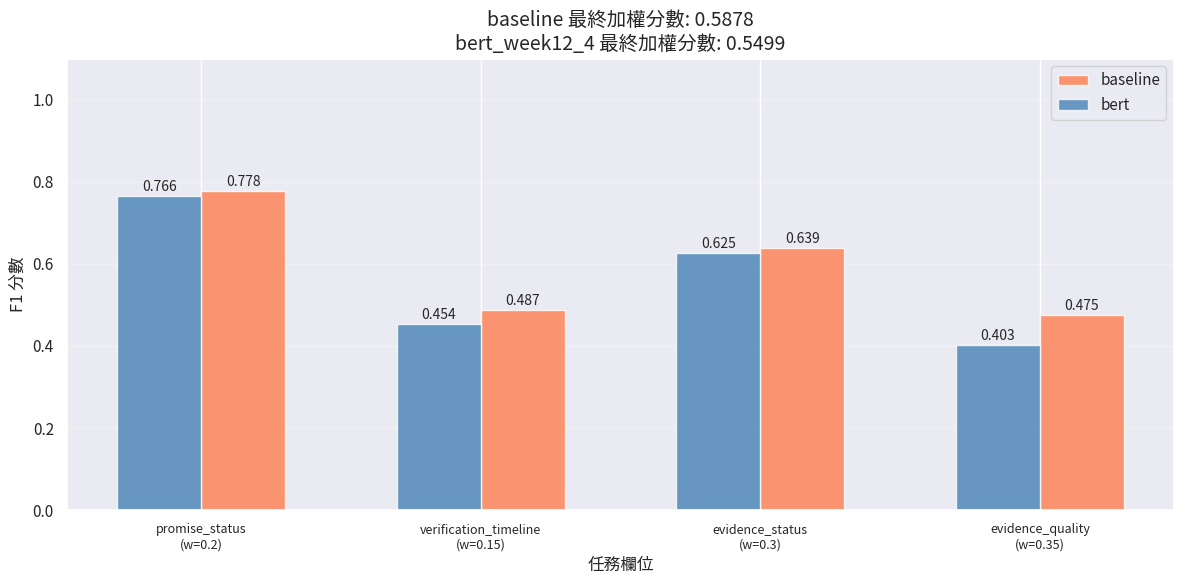

In [ ]:
# 視覺化各欄位的 F1 分數
fields = list(EVAL_FIELDS.keys())
macro_f1s = [final_results[f]["macro_f1"] for f in fields]
baseline = [0.778, 0.487, 0.639, 0.475]
weights = [0.20, 0.15, 0.30, 0.35]
baseline_weighted = sum(b * w for b, w in zip(baseline, weights))
x = range(len(fields))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar([i + width/2 for i in x], baseline, width, label='baseline',  color='coral',     alpha=0.8)
bars2 = ax.bar([i - width/2 for i in x], macro_f1s, width, label='bert', color='steelblue', alpha=0.8)

# 加上分數標籤
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel("任務欄位")
ax.set_ylabel("F1 分數")

title_text = (
    f"baseline 最終加權分數: {0.5878:.4f}\n"
    f"bert_week12_5 最終加權分數: {final_results['final_weighted_score']:.4f}"
)
ax.set_title(title_text, fontsize=14, fontweight='bold')
ax.set_xticks(list(x))
ax.set_xticklabels([f"{f}\n(w={w})" for f, w in zip(fields, weights)], fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax.legend()

plt.tight_layout()
plt.savefig("f1_scores.png", dpi=150, bbox_inches='tight')
plt.show()

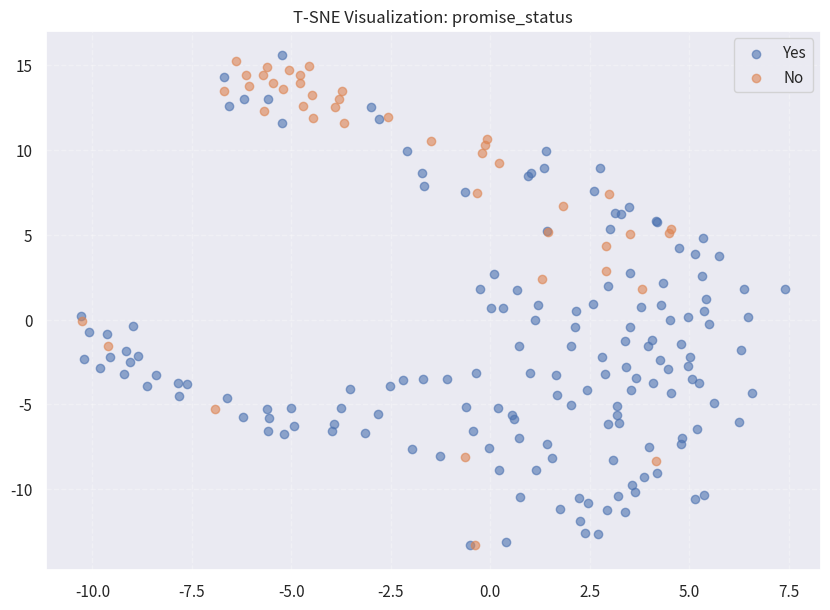

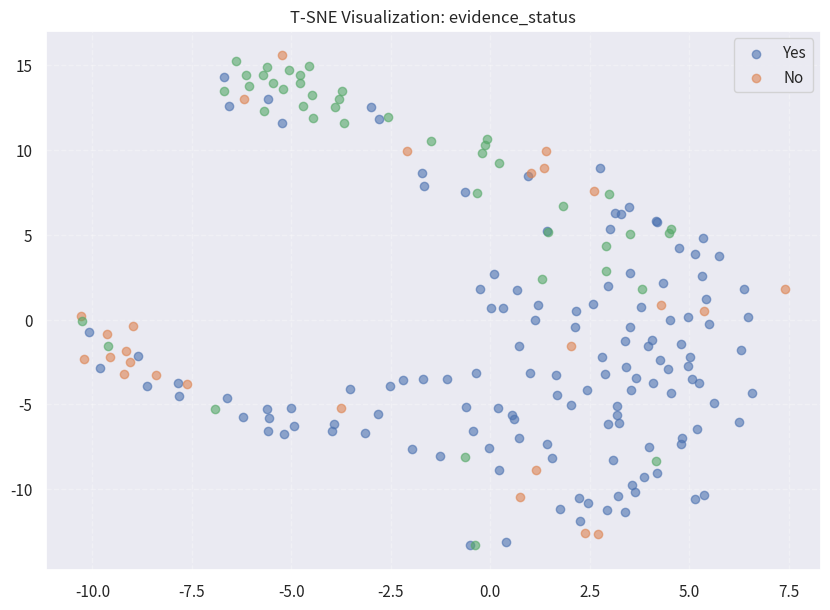

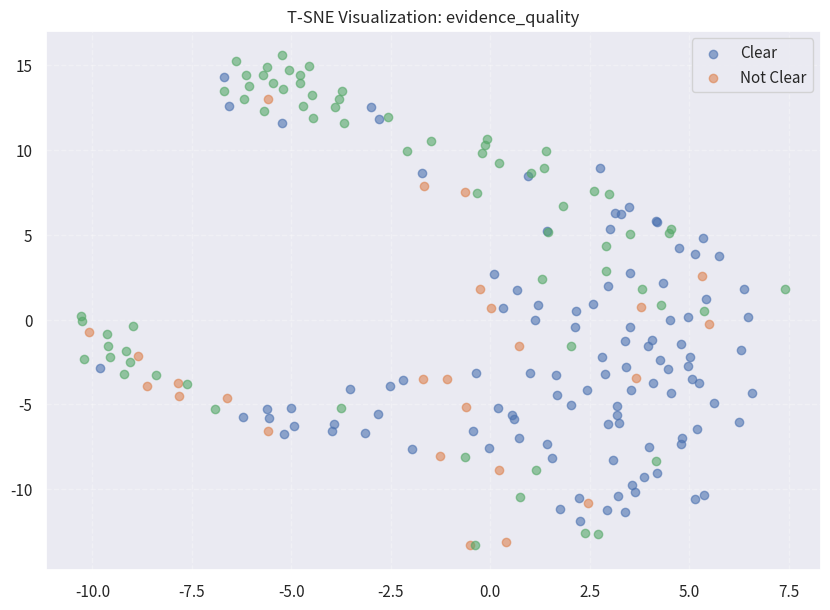

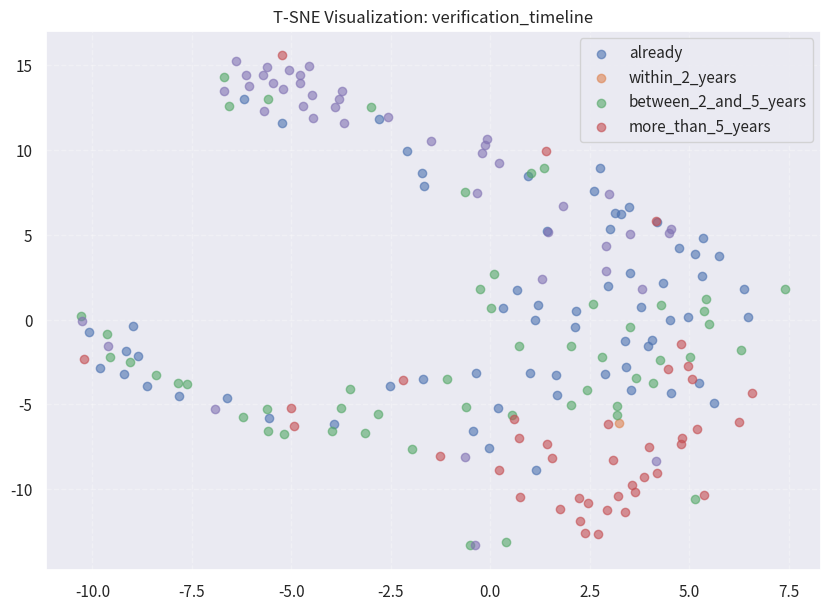

In [ ]:
from sklearn.manifold import TSNE
def plot_embedding_tsne_with_labels(model, dataloader, device, field_name='promise_status'):
    model.eval()
    embs, labels = [], []

    with torch.no_grad():
        for batch in dataloader:
            # 取得模型輸出
            out = model(batch["input_ids"].to(device),
                        batch["attention_mask"].to(device),
                        batch["extra_features"].to(device))

            # 收集 Embedding
            embs.append(out['embeddings'].cpu())
            # 收集標籤索引
            labels.extend(batch["labels"][field_name].numpy())

    embs = torch.cat(embs).numpy()

    # 執行 T-SNE 降維 (從 768 維降到 2 維)
    tsne = TSNE(n_components=2, init='pca', learning_rate='auto', random_state=42).fit_transform(embs)

    plt.figure(figsize=(10, 7))
    unique_labels = sorted(list(set(labels)))

    # 為每個類別單獨繪圖，方便顯示圖例 (Legend)
    for label_idx in unique_labels:
        mask = [l == label_idx for l in labels]
        # 從 id2label 找回名稱，若找不到則顯示索引
        label_name = id2label[field_name].get(label_idx, label_idx)
        plt.scatter(tsne[mask, 0], tsne[mask, 1], label=label_name, alpha=0.6)

    plt.legend()
    plt.title(f"T-SNE Visualization: {field_name}")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# 呼叫範例
plot_embedding_tsne_with_labels(model, val_loader, device, field_name='promise_status')
plot_embedding_tsne_with_labels(model, val_loader, device, field_name='evidence_status')
plot_embedding_tsne_with_labels(model, val_loader, device, field_name='evidence_quality')
plot_embedding_tsne_with_labels(model, val_loader, device, field_name='verification_timeline')

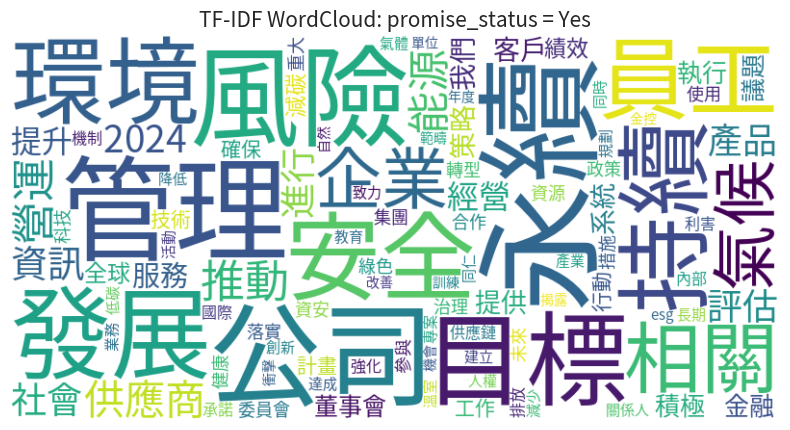

In [ ]:
# ============================================================
# 26. TF-IDF 文字雲（補入正確的 tfidf_vec/tfidf_train）
# ============================================================
from wordcloud import WordCloud

def generate_tfidf_wordcloud(target_field, target_label, data_subset, tfidf_vec, tfidf_matrix):
    indices    = [i for i, item in enumerate(data_subset) if item.get(target_field) == target_label]
    if not indices:
        print(f"⚠️  {target_field}={target_label} 在此子集中無資料，略過。")
        return
    sub_matrix = tfidf_matrix[indices]
    avg_tfidf  = sub_matrix.mean(axis=0).A1
    word_scores = {w: avg_tfidf[idx] for w, idx in tfidf_vec.vocabulary_.items()}

    wc = WordCloud(
        font_path='/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
        width=800, height=400, background_color='white', max_words=100
    )
    wc.generate_from_frequencies(word_scores)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"TF-IDF WordCloud: {target_field} = {target_label}", fontsize=15)
    plt.axis('off')
    plt.show()


generate_tfidf_wordcloud('promise_status','Yes',train_data, tfidf_vec, tfidf_train)